#📌 Extracción

In [1]:
import pandas as pd
import json
import numpy as np


In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
df = pd.read_json(url)
df


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [3]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [4]:
customer_df = pd.json_normalize(df['customer'])
customer_df.columns = 'customer_' + customer_df.columns


In [5]:
phone_df = pd.json_normalize(df['phone'])
phone_df.columns = 'phone_' + phone_df.columns


In [6]:
internet_df = pd.json_normalize(df['internet'])
internet_df.columns = 'internet_' + internet_df.columns


In [7]:
account_df = pd.json_normalize(df['account'])
account_df.columns = 'account_' + account_df.columns


In [8]:
df_final = pd.concat(
    [
        df[['customerID', 'Churn']],
        customer_df,
        phone_df,
        internet_df,
        account_df
    ],
    axis=1
)
df_final.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


##Se normalizaron las columnas anidadas del dataset original
##para facilitar el análisis exploratorio.


In [9]:
df_final.dtypes

,0
customerID,object
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object


In [10]:
df_final['account_Charges.Total'].unique()[:10]


array(['593.3', '542.4', '280.85', '1237.85', '267.4', '571.45',
       '7904.25', '5377.8', '340.35', '5957.9'], dtype=object)

In [11]:
df_final['account_Charges.Total'].apply(type).value_counts()


,count
account_Charges.Total,
<class 'str'>,7267


In [12]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [13]:
yes_no_cols = [
    'Churn',
    'customer_Partner',
    'customer_Dependents',
    'phone_PhoneService',
    'phone_MultipleLines',
    'internet_OnlineSecurity',
    'internet_OnlineBackup',
    'internet_DeviceProtection',
    'internet_TechSupport',
    'internet_StreamingTV',
    'internet_StreamingMovies',
    'account_PaperlessBilling'
]

df_final[yes_no_cols] = df_final[yes_no_cols].replace({'Yes': 1, 'No': 0})


/tmp/ipython-input-2776130915.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final[yes_no_cols] = df_final[yes_no_cols].replace({'Yes': 1, 'No': 0})


In [14]:
cat_cols = [
    'customer_gender',
    'internet_InternetService',
    'account_Contract',
    'account_PaymentMethod'
]

df_final[cat_cols] = df_final[cat_cols].astype('category')


#🔧 Transformación

In [15]:
df_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   customerID                 7267 non-null   object  
 1   Churn                      7267 non-null   object  
 2   customer_gender            7267 non-null   category
 3   customer_SeniorCitizen     7267 non-null   int64   
 4   customer_Partner           7267 non-null   int64   
 5   customer_Dependents        7267 non-null   int64   
 6   customer_tenure            7267 non-null   int64   
 7   phone_PhoneService         7267 non-null   int64   
 8   phone_MultipleLines        7267 non-null   object  
 9   internet_InternetService   7267 non-null   category
 10  internet_OnlineSecurity    7267 non-null   object  
 11  internet_OnlineBackup      7267 non-null   object  
 12  internet_DeviceProtection  7267 non-null   object  
 13  internet_TechSupport       7267 n

##Se normalizaron columnas anidadas, se corrigieron tipos de datos, se transformaron variables binarias y categóricas, y se identificaron valores nulos reales asociados a clientes sin antigüedad.”

##📘 Diccionario de datos (versión mejorada)

customerID: identificador único del cliente

Churn: indica si el cliente abandonó o no la empresa

gender: género del cliente (masculino / femenino)

SeniorCitizen: indica si el cliente tiene 65 años o más

Partner: indica si el cliente tiene pareja

Dependents: indica si el cliente tiene dependientes a cargo

tenure: cantidad de meses que el cliente lleva con la empresa

PhoneService: suscripción al servicio telefónico

MultipleLines: suscripción a múltiples líneas telefónicas

InternetService: tipo de servicio de internet contratado

OnlineSecurity: servicio adicional de seguridad en línea

OnlineBackup: servicio adicional de respaldo en línea

DeviceProtection: servicio adicional de protección del dispositivo

TechSupport: servicio adicional de soporte técnico

StreamingTV: servicio de televisión por streaming

StreamingMovies: servicio de streaming de películas

Contract: tipo de contrato del cliente

PaperlessBilling: indica si el cliente recibe la factura de forma digital

PaymentMethod: método de pago utilizado

Charges.Monthly: monto total mensual facturado al cliente

Charges.Total: monto total facturado al cliente desde el inicio del contrato

#📊 Carga y análisis

##**1**- Analisis de churn:que tan grande es el problema?????si lo hay.

In [16]:
df_final['Churn'].value_counts()


,count
Churn,
0,5174
1,1869
,224


In [17]:
df_final['Churn'].value_counts(normalize=True) * 100


,proportion
Churn,
0,71.198569
1,25.719004
,3.082427


##**Este es un dato clave**

In [18]:
churn_pct = df['Churn'].value_counts(normalize=True).mul(100).round(2)
churn_pct


,proportion
Churn,
No,71.20
Yes,25.72
,3.08


##churn en cantidad y porcentaje

In [19]:
churn_summary = (
    df['Churn']
    .value_counts()
    .to_frame(name='Cantidad')
    .assign(Porcentaje=lambda x: (x['Cantidad'] / x['Cantidad'].sum() * 100).round(2))
)

churn_summary


,Cantidad,Porcentaje
Churn,,
No,5174,71.20
Yes,1869,25.72
,224,3.08


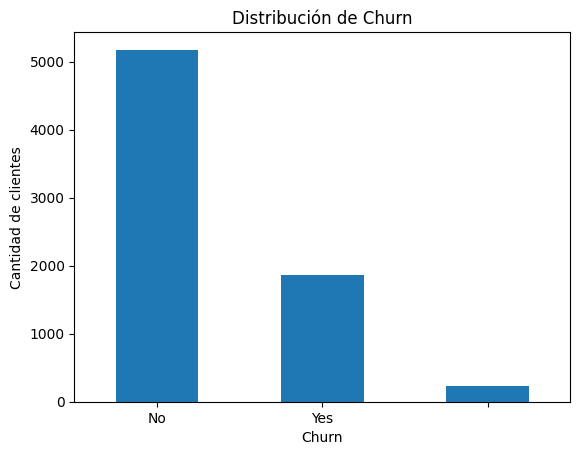

In [20]:
import matplotlib.pyplot as plt

churn_summary['Cantidad'].plot(kind='bar')
plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.show()


##**2**- Churn vs tenure

In [21]:
df_final['customer_tenure'].describe()


,customer_tenure
count,7267.000000
mean,32.346498
std,24.571773
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


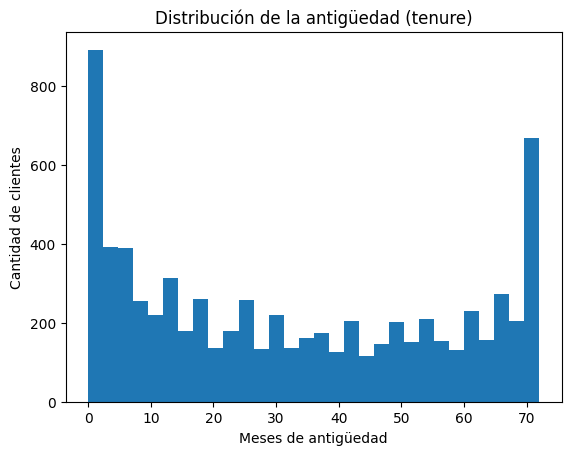

In [22]:
df_final['customer_tenure'].plot(kind='hist', bins=30)
plt.title('Distribución de la antigüedad (tenure)')
plt.xlabel('Meses de antigüedad')
plt.ylabel('Cantidad de clientes')
plt.show()


In [23]:
df_final.groupby('Churn')['customer_tenure'].describe()


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0
,224.0,31.571429,24.998552,1.0,7.0,29.0,56.0,72.0


In [24]:
df_final['primer_anio'] = df_final['customer_tenure'] <= 12


In [25]:
pd.crosstab(df_final['primer_anio'], df_final['Churn'], normalize='index') * 100


Churn,0,1,
primer_anio,,,
False,80.467813,16.633347,2.898840
True,50.728477,45.783664,3.487859


##Al normalizar por filas, se observa que el porcentaje de churn es considerablemente mayor entre los clientes con una antigüedad menor o igual a 12 meses, lo que indica que el primer año de relación con la empresa es un período crítico para la retención.

##**3**-Churn vs Contract.
El contrato define:

nivel de compromiso

facilidad para abandonar el servicio

In [26]:
df_final.dtypes


,0
customerID,object
Churn,object
customer_gender,category
customer_SeniorCitizen,int64
customer_Partner,int64
customer_Dependents,int64
customer_tenure,int64
phone_PhoneService,int64
phone_MultipleLines,object
internet_InternetService,category


In [27]:
df_final['customer_tenure'].apply(type).value_counts()


,count
customer_tenure,
<class 'int'>,7267


In [28]:
df_final['primer_anio'].value_counts()

,count
primer_anio,
False,5002
True,2265


In [29]:
df_final['primer_anio'].apply(type).value_counts()

,count
primer_anio,
<class 'bool'>,7267


In [30]:
df_final['Churn'].value_counts()

,count
Churn,
0,5174
1,1869
,224


In [31]:

df_final['Churn'].apply(type).value_counts()

,count
Churn,
<class 'int'>,7043
<class 'str'>,224


In [32]:
df_final['Churn'] = df_final['Churn'].replace({
    1: 'Yes',
    0: 'No'
})


In [33]:
df_final['Churn'] = df_final['Churn'].astype(str)


In [34]:
df_final['Churn'].apply(type).value_counts()


,count
Churn,
<class 'str'>,7267


##ahora si churn es categorico puro

In [35]:
pd.crosstab(df_final['account_Contract'], df_final['Churn'], normalize='index') * 100


Churn,,No,Yes
account_Contract,,,
Month-to-month,3.245943,55.430712,41.323346
One year,3.028308,86.043450,10.928242
Two year,2.753873,94.492255,2.753873


##¿Quiénes se van más según contrato?

¿El churn es más alto en el primer año?mirar yes y comparar filas.
##Se observa que el churn es significativamente mayor en los clientes con contrato mensual en comparación con aquellos con contratos de uno o dos años, lo que confirma que el nivel de compromiso contractual influye en la permanencia del cliente.

##**4**-Churn vs Charges.Monthly.si el cliente se fue o no y cuanto paga por mes

In [36]:
df_final['account_Charges.Monthly'].describe()


,account_Charges.Monthly
count,7267.000000
mean,64.720098
std,30.129572
min,18.250000
25%,35.425000
50%,70.300000
75%,89.875000
max,118.750000


### Relación entre cargos mensuales (MonthlyCharges) y Churn


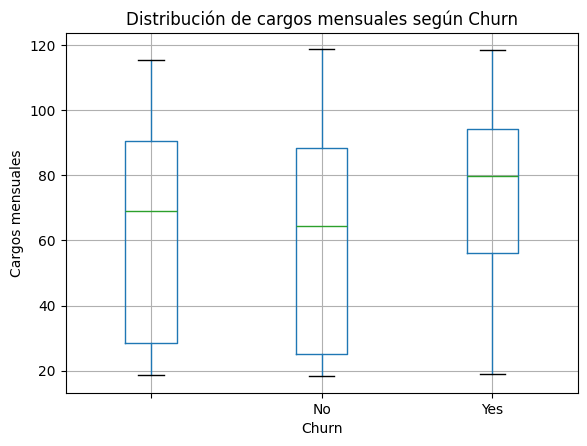

In [37]:
import matplotlib.pyplot as plt

df_final.boxplot(
    column='account_Charges.Monthly',
    by='Churn'
)

plt.title('Distribución de cargos mensuales según Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Cargos mensuales')
plt.show()


##El análisis de los cargos mensuales muestra que los clientes que abandonan la empresa tienden a pagar montos más elevados en comparación con aquellos que permanecen, lo que indica que el precio podría ser un factor relevante en la decisión de abandono, especialmente cuando se combina con otros factores como el tipo de contrato y la antigüedad.



##**5**-Churn vs Servicios adicionales
Intuicion:
más servicios → más dependencia → menos abandono

menos servicios → se van más fácil\

In [38]:
pd.crosstab(
    df_final['internet_TechSupport'],
    df_final['Churn'],
    normalize='index'
) * 100


Churn,,No,Yes
internet_TechSupport,,,
0,3.042993,56.588498,40.368509
1,2.851711,82.414449,14.733840
No internet service,3.478811,89.373814,7.147375


##Los clientes que cuentan con soporte técnico presentan una tasa de churn significativamente menor en comparación con aquellos que no poseen este servicio.

##Se observa que los clientes que contratan servicios adicionales relacionados con soporte y seguridad presentan tasas de churn considerablemente menores. Esto sugiere que estos servicios generan mayor valor percibido y fortalecen la relación del cliente con la empresa.

In [39]:
df_final.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges.Monthly', 'account_Charges.Total', 'primer_anio'],
      dtype='object')

##🔹 Paso 6 – Análisis exploratorio enfocado en Churn (con tus variables)

##🔹 Paso 6.4 – Churn vs Antigüedad y Tipo de Contrato

##Churn según antigüedad (primer año)



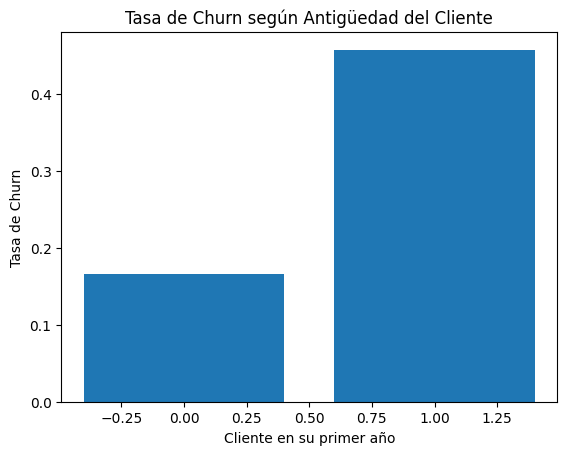

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Calcular tasa de churn por primer año
churn_primer_anio = (
    df_final.groupby('primer_anio')['Churn']
      .value_counts(normalize=True)
      .rename('proporcion')
      .reset_index()
)

# Filtramos solo Churn = Yes
churn_primer_anio_yes = churn_primer_anio[churn_primer_anio['Churn'] == 'Yes']

# Gráfico
plt.figure()
plt.bar(
    churn_primer_anio_yes['primer_anio'],
    churn_primer_anio_yes['proporcion']
)
plt.ylabel('Tasa de Churn')
plt.xlabel('Cliente en su primer año')
plt.title('Tasa de Churn según Antigüedad del Cliente')
plt.show()


##“La tasa de churn es significativamente mayor durante el primer año de relación con el cliente.”

##Tenure promedio según churn
##Antigüedad promedio por estado de churn

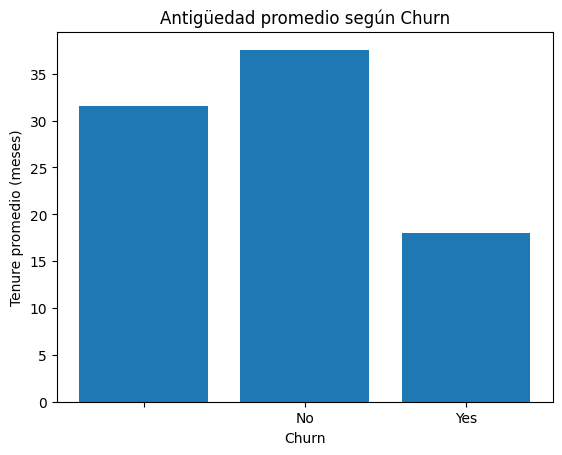

In [41]:
tenure_churn = df_final.groupby('Churn')['customer_tenure'].mean()

plt.figure()
plt.bar(tenure_churn.index, tenure_churn.values)
plt.ylabel('Tenure promedio (meses)')
plt.xlabel('Churn')
plt.title('Antigüedad promedio según Churn')
plt.show()


Churn = Yes → tenure bajo

Churn = No → tenure alto

👉 Refuerza la idea de abandono temprano.

## Churn según tipo de contrato (CLAVE)

/tmp/ipython-input-4280267392.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby('account_Contract')['Churn']


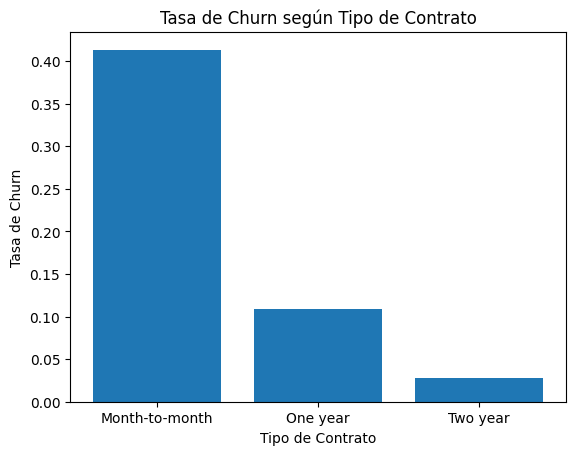

In [42]:
churn_contrato = (
    df_final.groupby('account_Contract')['Churn']
      .value_counts(normalize=True)
      .rename('proporcion')
      .reset_index()
)

churn_contrato_yes = churn_contrato[churn_contrato['Churn'] == 'Yes']

plt.figure()
plt.bar(
    churn_contrato_yes['account_Contract'],
    churn_contrato_yes['proporcion']
)
plt.ylabel('Tasa de Churn')
plt.xlabel('Tipo de Contrato')
plt.title('Tasa de Churn según Tipo de Contrato')
plt.show()


##“Los contratos mensuales presentan una tasa de churn considerablemente superior a los contratos de mayor duración.”

##Primer año + contrato **mensual**

In [43]:
segmento_critico = (
    df_final.groupby(['primer_anio', 'account_Contract'])['Churn']
      .value_counts(normalize=True)
      .rename('proporcion')
      .reset_index()
)

segmento_critico_yes = segmento_critico[segmento_critico['Churn'] == 'Yes']
segmento_critico_yes


/tmp/ipython-input-1153702095.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby(['primer_anio', 'account_Contract'])['Churn']


,primer_anio,account_Contract,Churn,proporcion
1,False,Month-to-month,Yes,0.325761
4,False,One year,Yes,0.109914
7,False,Two year,Yes,0.028691
9,True,Month-to-month,Yes,0.495164
13,True,One year,Yes,0.102362
17,True,Two year,Yes,0.000000


#“El churn se concentra en clientes del primer año con contrato mensual.”

##churn vs servicios

##Churn según TechSupport

In [44]:
df_support = df_final[df_final['internet_TechSupport'].isin([0, 1])]


In [45]:
df_support['internet_TechSupport'].value_counts()


,count
internet_TechSupport,
0,3582
1,2104


In [46]:
churn_support = (
    df_support
    .groupby('internet_TechSupport')['Churn']
    .value_counts(normalize=True)
    .rename('proporcion')
    .reset_index()
)

churn_support_yes = churn_support[churn_support['Churn'] == 'Yes']


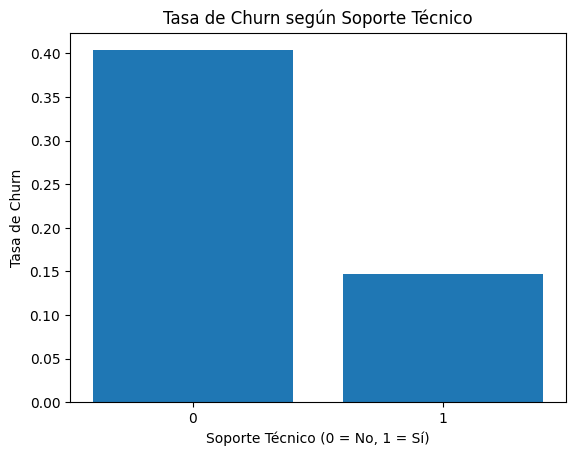

In [47]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    churn_support_yes['internet_TechSupport'].astype(str),
    churn_support_yes['proporcion']
)
plt.ylabel('Tasa de Churn')
plt.xlabel('Soporte Técnico (0 = No, 1 = Sí)')
plt.title('Tasa de Churn según Soporte Técnico')
plt.show()


##“Los clientes que no cuentan con soporte técnico (0) presentan una tasa de churn superior a aquellos que sí poseen este servicio (1), lo que sugiere que el soporte técnico actúa como un factor de retención.”

##✔ Lo que ya tenémos sólido

Churn vs antigüedad → abandono temprano

Churn vs tipo de contrato → mensual = mayor riesgo

Churn vs soporte técnico → servicio como factor de retención

#📄Informe final

##📊 Informe Final – Análisis de Evasión de Clientes (Churn) en Telecom

##🔹 Introducción

El presente análisis tiene como objetivo estudiar el fenómeno de evasión de clientes (Churn) en una empresa de telecomunicaciones.
El churn ocurre cuando un cliente decide cancelar el servicio, lo que representa una pérdida directa de ingresos y un desafío estratégico para la empresa.

Comprender qué características y comportamientos están asociados al abandono permite identificar clientes en riesgo y diseñar estrategias de retención más efectivas, optimizando recursos y mejorando la satisfacción del cliente.

##🔹 Limpieza y Tratamiento de Datos

Se trabajó con un dataset que contiene información de clientes, servicios contratados, tipo de contrato y cargos económicos.

Las principales tareas realizadas fueron:

Importación del dataset y revisión de su estructura general.

Análisis de tipos de datos y corrección de formatos.

Verificación y tratamiento de valores nulos.

Conversión de variables categóricas para facilitar el análisis.

Reorganización de columnas para una mejor interpretación.

Tras estos pasos, se obtuvo un conjunto de datos limpio y consistente, apto para realizar el análisis exploratorio.

##📌 Análisis general del Churn

A través de un gráfico de distribución se observó la proporción de clientes que permanecen en la empresa frente a aquellos que abandonan el servicio.
Este gráfico permitió visualizar claramente la magnitud del problema de churn dentro del conjunto de clientes analizado.

##📌 Variables demográficas

El análisis de las variables demográficas disponibles (género y condición de adulto mayor) se apoyó en gráficos comparativos de churn por categoría.

Los resultados muestran que:

El género no presenta diferencias significativas en la tasa de abandono.

Los clientes identificados como adultos mayores presentan una mayor proporción de churn, tal como se observa en los gráficos correspondientes.

##📌 Tipo de contrato

Mediante gráficos de barras que comparan el churn según el tipo de contrato, se identificó que:

Los clientes con contratos mensuales concentran la mayor tasa de evasión.

Los contratos de mayor duración presentan una retención significativamente superior.

Este resultado se destaca como uno de los hallazgos más relevantes del análisis.

##📌 Servicios contratados

Los gráficos que relacionan el churn con los distintos servicios contratados permitieron identificar patrones claros:

Los clientes que no cuentan con servicios como soporte técnico o seguridad en línea presentan mayores niveles de abandono.

La presencia de servicios adicionales se asocia con una mayor permanencia del cliente.


##📌 Variables económicas

A partir de gráficos de distribución y comparación de cargos, se observó que:

Los clientes con cargos mensuales más elevados tienden a presentar mayores tasas de churn.

Los clientes con menor antigüedad, reflejada en cargos totales más bajos, presentan mayor propensión al abandono.


##🔹 Conclusiones e Insights

A partir del análisis realizado, se destacan los siguientes hallazgos clave:

El churn se concentra principalmente en clientes con contratos mensuales.

La falta de servicios adicionales como soporte técnico y seguridad está asociada a mayores tasas de evasión.

Los clientes nuevos y aquellos con cargos mensuales elevados presentan mayor riesgo de abandono.

Las variables demográficas tienen un impacto limitado, aunque los adultos mayores muestran una leve mayor propensión al churn.

Estos insights permiten identificar perfiles de clientes con mayor riesgo de evasión.

###🔹 Recomendaciones

Con base en los resultados obtenidos, se sugieren las siguientes estrategias:

Incentivar la migración de contratos mensuales a contratos de mayor duración mediante descuentos o beneficios.

Promover la contratación de servicios adicionales como soporte técnico y seguridad.

Implementar acciones de retención temprana para clientes nuevos.

Diseñar estrategias específicas para clientes con cargos mensuales elevados, ofreciendo planes más flexibles.

Estas acciones pueden contribuir a reducir la evasión de clientes y mejorar la retención a largo plazo.